In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

DATA_DIR = Path(
    "/home/christian/Documents/research/MIST/mistsim/data/"
)

## Simulation cases

Test 0: Mars Site 2, mountain blockage up to 10 deg (nominal) \
Test 1: Same as 1, except no mountains \
Test 2: North Pole, no mountains

In [2]:
tests = {
    0: "MARS / with mountains",
    1: "MARS / no mountains",
    2: "North Pole / no mountains",
}
sim_res = {"raul": {}, "chb": {}}

## Raul's simulations

In [3]:
import h5py


def read_hdf5_convolution(path_file, print_key=False):
    with h5py.File(path_file, "r") as hf:
        if print_key:
            print([key for key in hf.keys()])

        hfX = hf.get("lst")
        lst = np.array(hfX)
        hfX = hf.get("freq")
        freq = np.array(hfX)
        hfX = hf.get("ant_temp")
        ant_temp = np.array(hfX)

    return lst, freq, ant_temp

# test 0
path = Path("20260215_for_christian/antenna_temperature_20260215_test1.hdf5")
lst, freqs, ant_temp_r = read_hdf5_convolution(DATA_DIR / path)
sim_res["raul"][0] = ant_temp_r

# test 1
path = Path("20260220_for_christian/antenna_temperature_20260220_test1.hdf5")
_lst, _freqs, ant_temp_r = read_hdf5_convolution(DATA_DIR / path)
assert np.allclose(lst, _lst)
assert np.allclose(freqs, _freqs)
sim_res["raul"][1] = ant_temp_r

# test 2
path = Path("20260220_for_christian/antenna_temperature_20260220_test2.hdf5")
_lst, _freqs, ant_temp_r = read_hdf5_convolution(DATA_DIR / path)
# assert np.allclose(lst, _lst)
lst_np = _lst  # north pole lst
assert np.allclose(freqs, _freqs)
sim_res["raul"][2] = ant_temp_r


lsts = {0: lst, 1: lst, 2: lst_np}

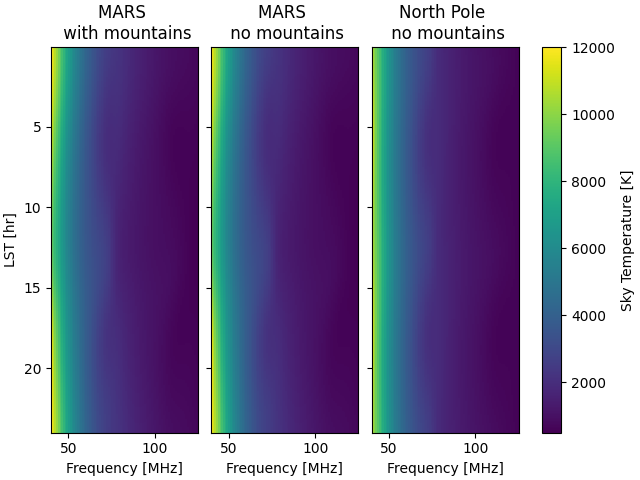

In [4]:
wfall_kwargs = {
    "extent": [freqs[0], freqs[-1], lst[-1], lst[0]],  # not exact for np
    "interpolation": "none",
    "aspect": "auto",
    "vmin": 500,
    "vmax": 12000,
}

fig, axs = plt.subplots(
    nrows=1, ncols=3, sharex=True, sharey=True, constrained_layout=True,
)
for k, v in sim_res["raul"].items():
    im = axs[k].imshow(v, **wfall_kwargs)
    axs[k].set_title("\n".join(tests[k].split("/")))
    axs[k].set_xlabel("Frequency [MHz]")
axs[0].set_ylabel("LST [hr]")
fig.colorbar(im, ax=axs, label="Sky Temperature [K]")
plt.show()

## MISTSIM

In [5]:
import jax

jax.config.update('jax_enable_x64', True)

In [6]:
import astropy.units as u
import croissant as cro
from astropy.coordinates import EarthLocation
from astropy.time import Time

import mistsim as ms

In [7]:
SIM_LMAX = 100

## Sky model

In [8]:
def scale_map(m, freqs, beta=-2.55, f0=408, tcmb=2.725):
    scale = (freqs/f0)**beta
    shape = (-1,) + (1,) * m.ndim
    return (m - tcmb)[None] * scale.reshape(shape) + tcmb

d = np.load(DATA_DIR / "haslam_galactic_mwss.npz")
m_ref = d["m"]  # single ref freq in MWSS sampling
f0_haslam = float(d["f0"])
haslam = scale_map(m_ref, freqs, f0=f0_haslam)

sky_model = ms.Sky(haslam, freqs, sampling="mwss", coord="galactic")

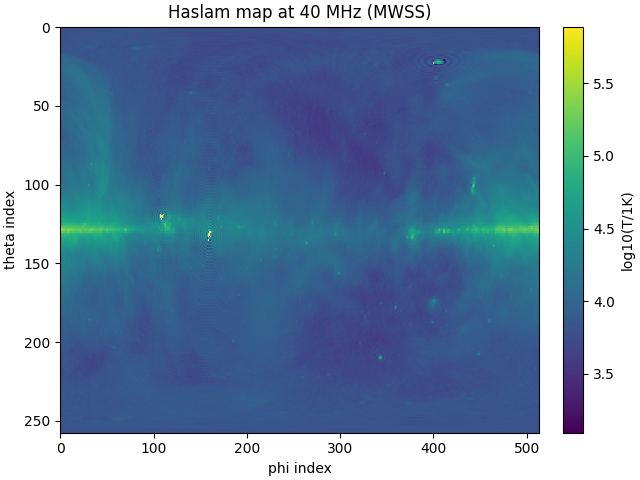

In [9]:
plt.figure(constrained_layout=True)
plt.imshow(
    np.log10(sky_model.data[0]),
    aspect="auto",
    interpolation="none",
    origin="upper",
)
plt.colorbar(label="log10(T/1K)")
plt.title(f"Haslam map at {freqs[0]:.0f} MHz (MWSS)")
plt.xlabel("phi index")
plt.ylabel("theta index")
plt.show()

## Beam model

Frequencies match: True
(86, 181, 360)


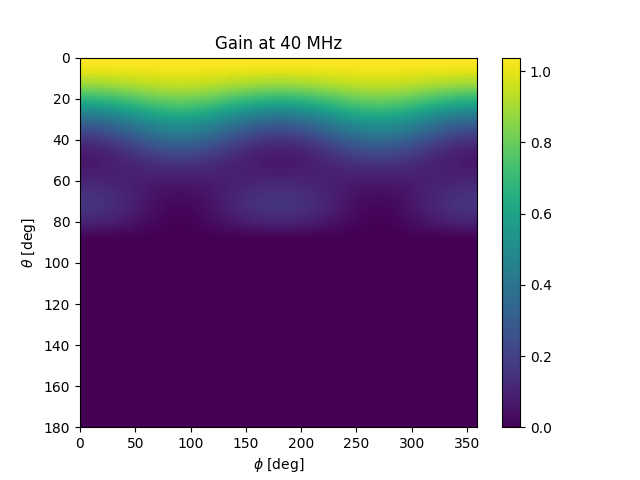

In [10]:
def load_beam(fname="feko_beam.npz"):
    d = np.load(DATA_DIR / Path(fname))
    freqs = d["freqs"]
    phi = d["phi"]
    theta = d["theta"]
    gain = d["gain"]
    return freqs, phi, theta, gain

freqs_beam, phi, theta, gain_above = load_beam()

# need to restrict to same freq range as sky
fix = np.isin(freqs_beam/1e6, freqs)
gain_above = gain_above[fix]
freqs_beam = freqs_beam[fix]
print(f"Frequencies match: {np.allclose(freqs_beam/1e6, freqs)}")

# theta needs to go 0 to 180
gain_below = np.zeros_like(gain_above[:, :-1, :])
gain = np.concatenate((gain_above, gain_below), axis=1)
print(gain.shape)

theta = np.concatenate((theta, np.arange(91, 181)))


plt.figure()
plt.imshow(
    gain[0], aspect="auto", interpolation="none", extent=[0, 359, 180, 0]
)
plt.colorbar()
plt.title(f"Gain at {freqs[0]:.0f} MHz")
plt.xlabel("$\\phi$ [deg]")
plt.ylabel("$\\theta$ [deg]")
plt.show()


# save the processed beam to beam.npz
beam_out = DATA_DIR / Path("beam.npz")
np.savez(beam_out, freqs=freqs_beam/1e6, phi=phi, theta=theta, gain=gain)

In [11]:
BEAM_AZ_ROT = 90  # EAST x-axis

# no mountain case (test 1 and 2)
beam2 = ms.Beam(gain, freqs, sampling="mwss", horizon=None,
                beam_az_rot=BEAM_AZ_ROT)

# with mountain blockage
horizon = theta <= 80
horizon = horizon[:, None]
beam1 = ms.Beam(gain, freqs, sampling="mwss", horizon=horizon,
                beam_az_rot=BEAM_AZ_ROT)

# test 0: with mountains, 1,2: no mountains
beams = {0: beam1, 1: beam2, 2: beam2}

## Simulator

In [12]:
# define observation time and location

# mars
lon = -90.74750
lat = 79.41833
alt = 150
loc = EarthLocation.from_geodetic(lon, lat, height=alt)
locs = {0: loc, 1: loc}

# north pole
np_loc = EarthLocation.from_geodetic(0, 90, height=0)
locs[2] = np_loc
print(locs)


def lst_to_time(lst_arr, t0):
    """
    Convert array of LST to array of astropy Time objects
    for use with croissant

    Parameters
    ----------
    lst_arr : array_like
        List of LST in hrs
    t0 : Time
        Reference time.
    """
    lst_ref = t0.sidereal_time("mean").hour
    delta = (lst_arr - lst_ref) /24 * u.sday
    times = t0 + delta
    return times

times = {}
for k, loc in locs.items():
    t0 = Time("2022-07-17 00:00", location=loc)
    times[k] = lst_to_time(lsts[k], t0)

for k, t in times.items():
    print(f"LST match: {np.allclose(t.sidereal_time('mean').hour, lsts[k])}")

np.savez(
    DATA_DIR / Path("mars.npz"),
    lst=lsts[0],
    times_jd=times[0].jd,
    lon=lon,
    lat=lat,
    alt=alt,
)

{0: <EarthLocation (-15330.25523412, -1174995.43673812, 6248087.82372465) m>, 1: <EarthLocation (-15330.25523412, -1174995.43673812, 6248087.82372465) m>, 2: <EarthLocation (3.91862092e-10, 0., 6356752.31424518) m>}
LST match: True
LST match: True
LST match: True


In [13]:
sims = {}

for k in range(3):
    print(f"Set up simulation {k}")
    beam = beams[k]
    times_jd = times[k].jd
    lon = locs[k].lon.deg
    lat = locs[k].lat.deg
    alt = locs[k].height.value
    sim = ms.Simulator(
        beam,
        sky_model,
        times_jd,
        freqs,
        lon,
        lat,
        alt=alt,
        lmax=SIM_LMAX,
        Tgnd=0,
    )
    sims[k] = sim

Set up simulation 0
Set up simulation 1
Set up simulation 2


In [14]:
tants = {}
for k, sim in sims.items():
    print(f"Run simulation {k}")
    tant = sim.sim()
    tants[k] = tant
    fgnd = sim.beam.compute_fgnd()
    tsky = cro.simulator.correct_ground_loss(tant, fgnd, 0)  # Tgnd=0
    sim_res["chb"][k] = tsky

Run simulation 0
Run simulation 1
Run simulation 2


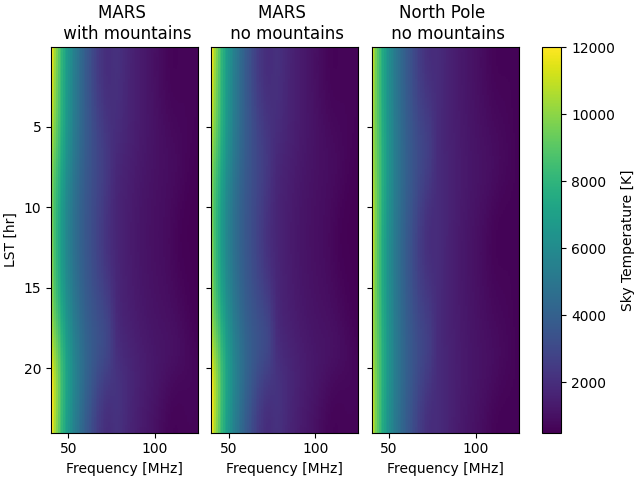

In [15]:
fig, axs = plt.subplots(
    nrows=1, ncols=3, sharex=True, sharey=True, constrained_layout=True,
)
for k, v in sim_res["chb"].items():
    im = axs[k].imshow(v, **wfall_kwargs)
    axs[k].set_title("\n".join(tests[k].split("/")))
    axs[k].set_xlabel("Frequency [MHz]")
axs[0].set_ylabel("LST [hr]")
fig.colorbar(im, ax=axs, label="Sky Temperature [K]")
plt.show()

## Save results

In [16]:
def flatten_dict(d):
    """
    Flatten a nestesd dictionary
    """
    flat_d = {}
    for outerkey, inner in d.items():
        for innerkey, v in inner.items():
            k = "-".join([str(outerkey), str(innerkey)])
            flat_d[k] = np.asarray(v)
    return flat_d


SAVE = False
if SAVE:
    flat_res = flatten_dict(sim_res)
    np.savez(
        "comparison_022526.npz",
        **flat_res,
        sky_map=sky_model.data,
        beam_data=beam1.data,
        freqs=freqs,
        lst=lst,
        tests=tests,
    )

## Compare Raul's sim with MISTSIM

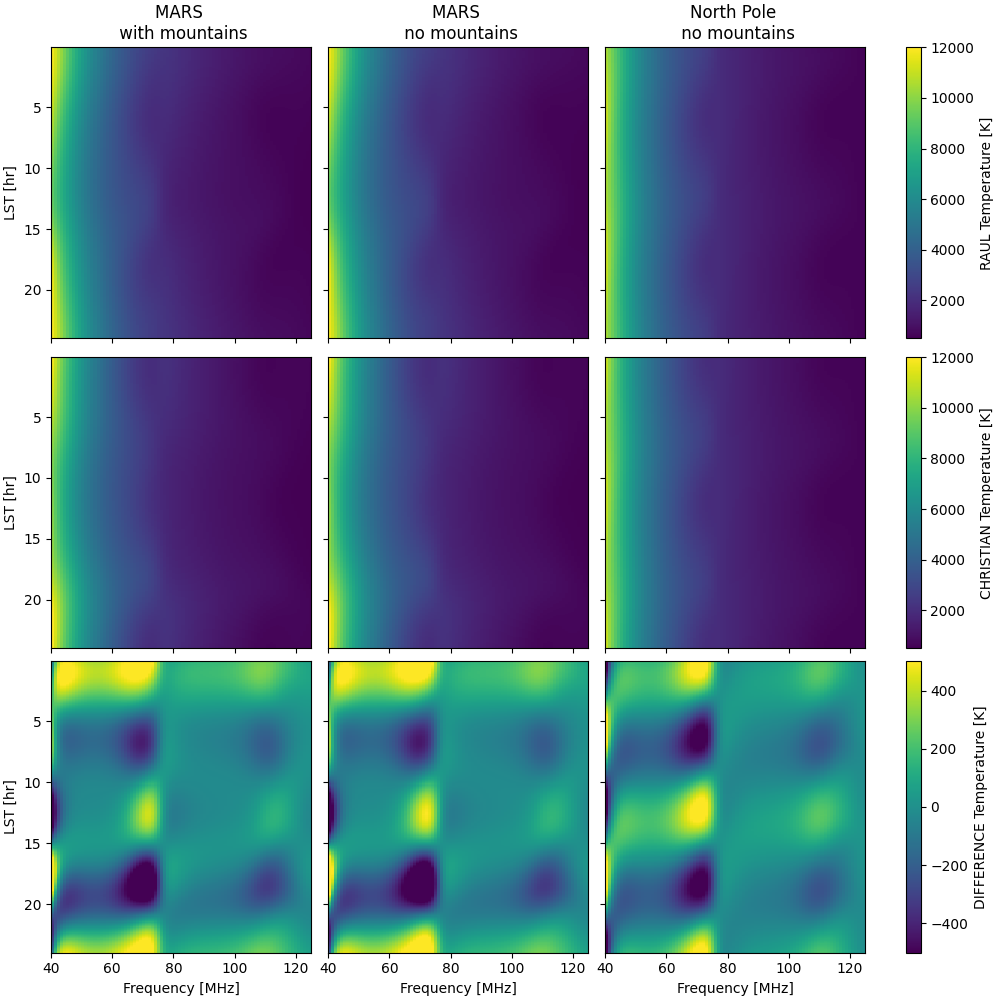

In [20]:
diff_kwargs = wfall_kwargs.copy()
diff_kwargs["vmin"] = -500
diff_kwargs["vmax"] = 500

fig, axs = plt.subplots(
    figsize=(10, 10),
    nrows=3,
    ncols=3,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for k in sim_res["chb"]:
    raul_sim = sim_res["raul"][k]
    chb_sim = sim_res["chb"][k]
    diff = raul_sim - chb_sim
    imr = axs[0, k].imshow(raul_sim, **wfall_kwargs)
    imc = axs[1, k].imshow(chb_sim, **wfall_kwargs)
    imd = axs[2, k].imshow(diff, **diff_kwargs)
    axs[0, k].set_title("\n".join(tests[k].split("/")))
    axs[2, k].set_xlabel("Frequency [MHz]")

fig.colorbar(imr, ax=axs[0], label="RAUL Temperature [K]")
fig.colorbar(imc, ax=axs[1], label="CHRISTIAN Temperature [K]")
fig.colorbar(imd, ax=axs[2], label="DIFFERENCE Temperature [K]")
plt.setp(axs[:, 0], ylabel="LST [hr]")

plt.show()

### Impact of horizon

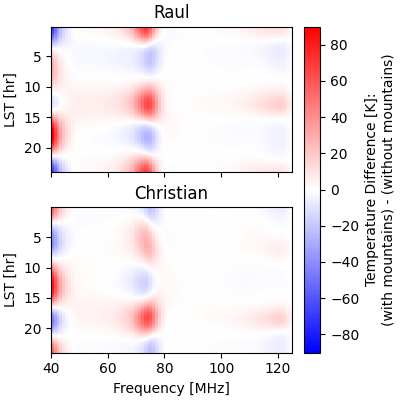

In [18]:
diff_horizon_raul = sim_res["raul"][1] - sim_res["raul"][0]
diff_horizon_chb = sim_res["chb"][1] - sim_res["chb"][0]

h_kwargs = diff_kwargs.copy()
h_kwargs["cmap"] = "bwr"
h_kwargs["vmin"] = -90
h_kwargs["vmax"] = 90

fig, axs = plt.subplots(
    figsize=(4, 4),
    nrows=2,
    ncols=1,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
im = axs[0].imshow(diff_horizon_raul, **h_kwargs)
im = axs[1].imshow(diff_horizon_chb, **h_kwargs)
axs[-1].set_xlabel("Frequency [MHz]")
plt.setp(axs, ylabel="LST [hr]")
axs[0].set_title("Raul")
axs[1].set_title("Christian")
fig.colorbar(
    im,
    ax=axs,
    label=(
        "Temperature Difference [K]:\n(with mountains) - (without mountains)"
    ),
)
plt.show()

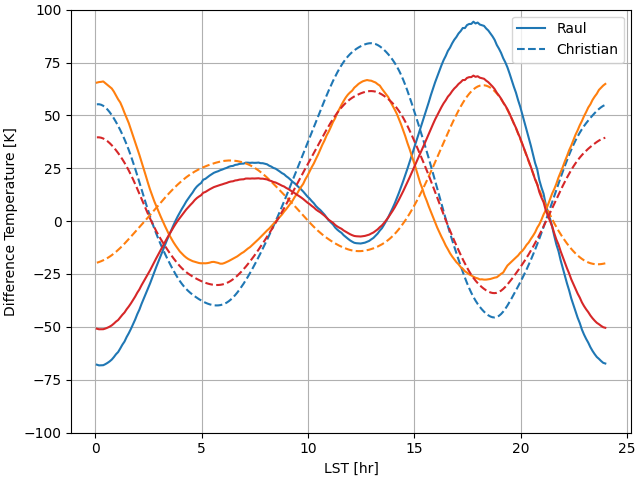

In [19]:
fmd = np.argsort(np.sum(np.abs(diff_horizon_raul), axis=0))[::-1]
plt.figure(constrained_layout=True)
for i in range(4):
    if i == 2:
        continue
    c = f"C{i}"
    ix = fmd[i]
    plt.plot(lst, diff_horizon_raul[:, ix], c=c, ls="-", label="Raul")
    plt.plot(lst, diff_horizon_chb[:, ix], c=c, ls="--", label="Christian")
    if i == 0:
        plt.legend(loc="upper right")
#plt.legend(bbox_to_anchor=[1., 1.])
#plt.legend(loc="upper right")
plt.xlabel("LST [hr]")
plt.ylabel("Difference Temperature [K]")
plt.grid()
plt.ylim(-100, 100)
plt.show()